# Import Library

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from tensorflow.keras.regularizers import l2

In [4]:
X_train = pd.read_csv('X_train final.csv').values
y_train = pd.read_csv('y_train final.csv').values
X_test = pd.read_csv('X_test final.csv').values
y_test = pd.read_csv('y_test final.csv').values

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Proses Modelling

In [5]:
def build_fintrack_model():
    inputs = tf.keras.Input(shape=(input_dim,))

    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(32, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(16, activation='relu')(x)


    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs, name="FinTrack_Classifier")
    return model

model = build_fintrack_model()

In [6]:
class finTracktargetCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('accuracy')
        mae = logs.get('mae')

        if acc is not None and mae is not None:
            if acc >= 0.85 and mae <= 0.02:
                print(f"\n[info] target tercapai di epoch {epoch+1}!")
                print(f"Akurasi: {acc:.4f}, MAE: {mae:.4f}. menghentikan training...")
                self.model.stop_training = True

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'mae']
)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[finTracktargetCallback()],
    verbose=1
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6354 - loss: 1.3070 - mae: 0.4275 - val_accuracy: 0.7906 - val_loss: 1.1703 - val_mae: 0.3950
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8087 - loss: 1.0347 - mae: 0.3063 - val_accuracy: 0.9738 - val_loss: 0.9223 - val_mae: 0.2734
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9487 - loss: 0.7734 - mae: 0.1720 - val_accuracy: 1.0000 - val_loss: 0.6714 - val_mae: 0.1292
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.5889 - mae: 0.0760 - val_accuracy: 1.0000 - val_loss: 0.5225 - val_mae: 0.0509
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9897 - loss: 0.5083 - mae: 0.0526 - val_accuracy: 1.0000 - val_loss: 0.4339 - val_mae: 0.0223
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9910 - loss: 0.4285 - mae: 0.0356 - val_accuracy: 1.0000 - val_loss: 0.3706 - val_mae: 0.0125
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

# Visualisasi

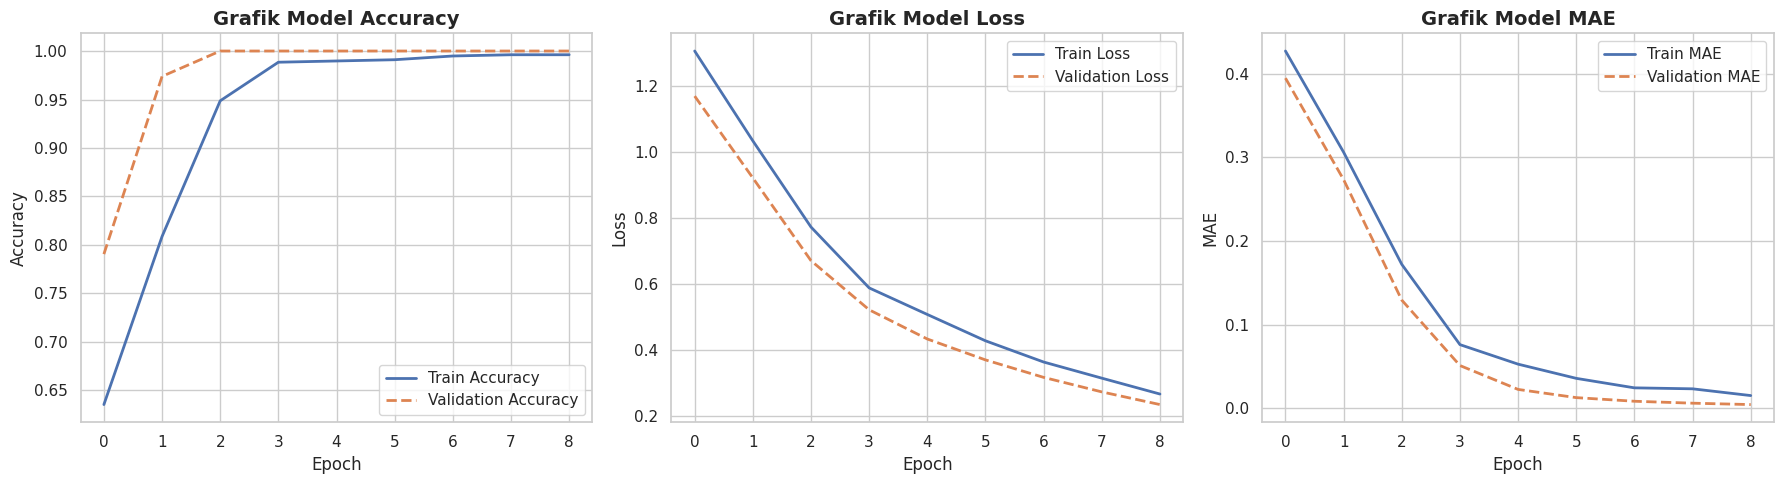

In [9]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# akurasi (Accuracy)
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='#4C72B0', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#DD8452', linewidth=2, linestyle='--')
axes[0].set_title('Grafik Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')

# loss (Binary Crossentropy)
axes[1].plot(history.history['loss'], label='Train Loss', color='#4C72B0', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='#DD8452', linewidth=2, linestyle='--')
axes[1].set_title('Grafik Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')

# MAE (Mean Absolute Error)
axes[2].plot(history.history['mae'], label='Train MAE', color='#4C72B0', linewidth=2)
axes[2].plot(history.history['val_mae'], label='Validation MAE', color='#DD8452', linewidth=2, linestyle='--')
axes[2].set_title('Grafik Model MAE', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MAE')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Simpan model

In [10]:
model.save("fintrack_model.keras")
print("Model berhasil disimpan dalam format fintrack_model.keras")

Model berhasil disimpan dalam format fintrack_model.keras


# Proses Inference Sederhana

In [11]:
model_fintrack = tf.keras.models.load_model("fintrack_model.keras")

profil_keuangan = {
    1: "Mahasiswa konsumtif (Tinggi di hiburan & sosial)",
    0: "Mahasiswa terencana (Prioritas kebutuhan pokok & kos)"
}

def predict_user_profile(data_input_user):
    prediksi_probabilitas = model_fintrack.predict(data_input_user)

    nilai_prob = float(prediksi_probabilitas[0][0])

    if nilai_prob >= 0.5:
        cluster_id = 1
    else:
        cluster_id = 0

    hasil_prediksi = {
        "status": "success",
        "cluster_id": cluster_id,
        "kesimpulan": profil_keuangan[cluster_id],
        "confidence_score": round(nilai_prob, 4)
    }

    return hasil_prediksi

data_dummy = pd.read_csv('X_test final.csv').values[:1]

hasil = predict_user_profile(data_dummy)
print("Data:", hasil)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Data: {'status': 'success', 'cluster_id': 0, 'kesimpulan': 'Mahasiswa terencana (Prioritas kebutuhan pokok & kos)', 'confidence_score': 0.0179}


# Fitur Finbot (Tambahan)

In [ ]:
import os
import joblib
from groq import Groq

# Konfigurasi API key
DAFTAR_API = []
index_key_groq = 0

scaler = joblib.load("scaler final (1).pkl")
model_kmeans = joblib.load("model_clustering final.pkl")


profil_cluster = {
    0: "Mahasiswa boros",
    1: "Mahasiswa hemat",
}

nama_kolom = [
    'age', 'gender', 'year_in_school', 'major', 'monthly_income',
    'financial_aid', 'tuition', 'housing', 'food', 'transportation',
    'books_supplies', 'entertainment', 'personal_care', 'technology',
    'health_wellness', 'miscellaneous', 'preferred_payment_method',
    'total_spending', 'saving_ratio', 'spending_level'
]


#  Prediksi cluster
def dapatkan_profil_otomatis(data_transaksi_user):
    # Mengubah list menjadi DataFrame
    df_input = pd.DataFrame([data_transaksi_user], columns=nama_kolom)

    # Standarisasi data & prediksi cluster
    data_scaled = scaler.transform(df_input)
    cluster_id = model_kmeans.predict(data_scaled)[0]

    return profil_cluster[cluster_id]


def chatbot_finbot(pertanyaan_user, profil_cluster_ds, saldo_saat_ini):
    global index_key_groq
    jumlah_kunci = len(DAFTAR_API)
    percobaan = 0

    system_prompt = f"""
    Kamu adalah 'FinBot', asisten penasihat keuangan pintar dan empatik di aplikasi FinTrack.
    Gaya bahasamu asyik, suportif, dan kekinian (cocok untuk Gen Z / Mahasiswa).

    Konteks profil pengguna saat ini:
    - Kategori pengguna: {profil_cluster_ds}
    - Sisa saldo saat ini: Rp {saldo_saat_ini:,}

    Aturan menjawab:
    1. Jawab pertanyaan pengguna berdasarkan profil dan sisa saldo mereka.
    2. Jawab dengan singkat, padat, dan solutif (maksimal 3 paragraf).
    """

    while percobaan < jumlah_kunci:
        kunci_saat_ini = DAFTAR_API[index_key_groq]
        try:
            client = Groq(api_key=kunci_saat_ini)
            chat_completion = client.chat.completions.create(
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": pertanyaan_user}
                ],
                model="llama-3.3-70b-versatile",
                temperature=0.7
            )
            return chat_completion.choices[0].message.content
        except Exception as e:
            # Jika limit, pindah ke API Key berikutnya otomatis
            index_key_groq = (index_key_groq + 1) % jumlah_kunci
            percobaan += 1

    return "Waduh, server FinBot lagi kepenuhan nih! Coba beberapa saat lagi ya."

In [14]:
# contoh simulasi data transaksi
data_transaksi = [
    20, 1, 0, 2,        # age, gender, year_in_school, major
    2000000, 500000,    # monthly_income, financial_aid
    1500000, 800000,    # tuition, housing
    400000, 150000,     # food, transportation
    100000, 200000,     # books_supplies, entertainment
    50000, 120000,      # personal_care, technology
    80000, 30000,       # health_wellness, miscellaneous
    1,                  # preferred_payment_method
    3430000, 0.15, 2    # total_spending, saving_ratio, spending_level
]
saldo_sekarang = int(input("Masukkan saldo user: "))
pertanyaan = input("Masukkan pertanyaan user: ")

cluster_otomatis = dapatkan_profil_otomatis(data_transaksi)
jawaban_ai = chatbot_finbot(pertanyaan, cluster_otomatis, saldo_sekarang)

# hasil akhir
print(f"Hasil deteksi cluster   : {cluster_otomatis}")
print(f"Sisa saldo user         : Rp {saldo_sekarang:,}")
print(f"Pertanyaan user         : '{pertanyaan}'")
print("="*60)
print("Respon Finbot :")
print(jawaban_ai)
print("="*60)

Masukkan saldo user: 50000
Masukkan pertanyaan user: "eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya, mending ikut atau nggak?"


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


Hasil deteksi cluster   : Mahasiswa boros
Sisa saldo user         : Rp 50,000
Pertanyaan user         : '"eh FinBot, temen-temen kelasan ngajak nongkrong ke kafe mahal nih nanti malam. gimana ya, mending ikut atau nggak?"'
Respon Finbot :
Kamu lagi dihadapkan pada pilihan yang sulit nih. Tapi, perlu diingat bahwa sisa saldo kamu saat ini hanya Rp 50,000. Nongkrong di kafe mahal bisa membuat kamu mengeluarkan uang yang cukup besar, dan itu bisa membuat kamu kehabisan uang.

Mending kamu pertimbangkan lagi, deh. Apakah nongkrong di kafe mahal itu benar-benar penting bagi kamu? Atau kamu bisa mencari alternatif lain yang lebih murah, seperti nongkrong di kantin kampus atau di rumah teman. Dengan begitu, kamu bisa tetap bersama teman-temanmu tanpa harus mengeluarkan uang yang terlalu banyak.

Jika kamu masih ingin ikut, coba kamu buat anggaran dulu, ya. Hitung berapa uang yang kamu butuhkan untuk nongkrong di kafe mahal dan bandingkan dengan sisa saldo kamu. Jika kamu masih memiliki uang y